### Import

In [1]:
import os
import gc
import time
import pickle 
import itertools
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm
import matplotlib.ticker as ticker
from matplotlib import pyplot as plt 

from typing import Dict
from typing import Callable
from plot_metric.functions import BinaryClassification

import statsmodels.api as sm
from scipy.stats import spearmanr

from pynvml import *
import GPUtil
from threading import Thread

from sklearn.metrics import auc
from sklearn.metrics import f1_score 
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from aequitas.bias import Bias
from aequitas.group import Group
from aequitas.plotting import Plot
from aequitas.fairness import Fairness

import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.utils.data.sampler import WeightedRandomSampler

from torch.nn.utils.rnn import pad_packed_sequence
from torch.nn.utils.rnn import pack_padded_sequence

from torch.optim import AdamW
from transformers import get_scheduler
from transformers import get_linear_schedule_with_warmup

from captum.attr import IntegratedGradients

pd.set_option('display.max_columns', 500)

### General parameters

In [2]:
race_path   = "Extraction/MIMICIII/Data/csvExtract/"
path_cohort = "../Data/Cohorts/"
best_model  = "../checkpoints/Fusion/"
path_ehr    = "../Data/EHR/"
path_data   = "../Data/Representations/TEXT/"

### Read Cohorts Splits

In [3]:
with open(path_cohort + "short_icustays", "rb") as fp:   
    short_icustays = pickle.load(fp)
    
with open(path_cohort + "train_icustays", "rb") as fp:   
    train_icustays = pickle.load(fp)
    
with open(path_cohort + "valid_icustays", "rb") as fp:   
    valid_icustays = pickle.load(fp)
    
with open(path_cohort + "test_icustays", "rb") as fp:   
    test_icustays = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_text", "rb") as fp:   
    icustays_ehr_text = pickle.load(fp)
    
with open(path_cohort + "icustays_ehr_only", "rb") as fp:   
    icustays_ehr_only = pickle.load(fp)
    
with open(path_cohort + "note_ids_24h", "rb") as fp:   
    note_ids_24h = pickle.load(fp)

### Reading Data

In [4]:
df_notes = pd.read_csv(path_data + 'text_llm_representation.csv', low_memory=False, index_col=False)
df_notes.head(2)

In [5]:
print(df_notes.ICUSTAY_ID.nunique())
print(df_notes.shape)

48211
(242757, 777)


### Represent each unique Note & Image Vector

In [6]:
df_note_ids = pd.read_csv(path_ehr + 'all_note_ids.csv', low_memory=False, index_col=False)
df_note_ids = df_note_ids[['ICUSTAY_ID', 'Bins', 'Note']]
df_note_ids = df_note_ids.rename(columns={"Note": "ROW_ID"})
df_note_ids.head(2)

In [7]:
df_stayid = df_notes[['ICUSTAY_ID', 'GENDER', 'ETHNICITY', 'AGE', 'ICU_EXPIRE_FLAG', 'ROW_ID']].copy()
df_stayid = df_stayid.drop_duplicates()
df_stayid = df_stayid.merge(df_note_ids, on=['ICUSTAY_ID', 'ROW_ID'], how='left')
df_stayid = df_stayid.sort_values(by=['ICUSTAY_ID', 'ROW_ID'])
df_stayid = df_stayid.reset_index(drop=True)

In [9]:
df_notes = df_notes.drop(['GENDER', 'ETHNICITY', 'AGE', 'ICU_EXPIRE_FLAG', 'True_Label', 'ICU_FLAG'], axis=1)
df_notes = df_notes.groupby(['ICUSTAY_ID', 'ROW_ID']).mean().reset_index()
df_notes.head(3)

In [11]:
df_notes = df_stayid.merge(df_notes, on=['ICUSTAY_ID', 'ROW_ID'], how='left')
df_notes.head(3)

In [12]:
print(df_notes.ICUSTAY_ID.nunique())
print(df_notes.shape)

48211
(211468, 776)


### Take first 24 hour LoS

In [13]:
df_notes = df_notes[df_notes.ROW_ID.isin(note_ids_24h)]
df_notes = df_notes.sort_values(by=['ICUSTAY_ID', 'ROW_ID'])
df_notes = df_notes.reset_index(drop=True)

In [14]:
df_notes.head(3)

In [15]:
print(df_notes.ICUSTAY_ID.nunique())
print(df_notes.shape)

48211
(211468, 776)


### Spliting Train - Validation - Test

In [16]:
label = 'ICU_EXPIRE_FLAG'

In [17]:
train_df = df_notes[df_notes.ICUSTAY_ID.isin(train_icustays)]
valid_df = df_notes[df_notes.ICUSTAY_ID.isin(valid_icustays)]
test_df  = df_notes[df_notes.ICUSTAY_ID.isin(test_icustays)]

train_df.sort_values(by=['ICUSTAY_ID', 'Bins', 'ROW_ID'], inplace=True)
valid_df.sort_values(by=['ICUSTAY_ID', 'Bins', 'ROW_ID'], inplace=True)
test_df.sort_values( by=['ICUSTAY_ID', 'Bins', 'ROW_ID'], inplace=True)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

In [19]:
del df_notes
gc.collect()

20

### Variables Selection

In [20]:
note_encoding_dim = 768
note_columns = [f'embeded_dim{i+1}' for i in range(note_encoding_dim)]

note_columns.extend(['Predicted_Probability'])

### Prepare Test Result Frame

In [21]:
def result_frame(data, label):
        
    result = data.groupby(['ICUSTAY_ID'])[['ICUSTAY_ID', 'GENDER', 'AGE', 'ETHNICITY', label]].head(1).copy()
    
    result['ICU_FLAG'] = np.nan
    result.loc[result['ICU_EXPIRE_FLAG'] == 0, 'ICU_FLAG'] = 'Survived'
    result.loc[result['ICU_EXPIRE_FLAG'] == 1, 'ICU_FLAG'] = 'Dead'
    
    return result

In [22]:
train_result = result_frame(train_df, label)
valid_result = result_frame(valid_df, label)
test_result  = result_frame(test_df , label)

train_result = train_result.reset_index(drop=True)
valid_result = valid_result.reset_index(drop=True)
test_result  = test_result.reset_index(drop=True)

### Normalization

In [23]:
def Normalizing(train_df, valid_df, test_df, note_columns):
        
    train_val = train_df[note_columns]
    valid_val = valid_df[note_columns]
    test_val  = test_df[note_columns]

    scaler = MinMaxScaler().fit(train_val.values)

    train_normalized = scaler.transform(train_val.values)
    valid_normalized = scaler.transform(valid_val.values)
    test_normalized  = scaler.transform(test_val.values)

    train_df[norm] = train_normalized
    valid_df[norm] = valid_normalized
    test_df[norm]  = test_normalized

    train_df = train_df.round(2)
    valid_df = valid_df.round(2)
    test_df  = test_df.round(2)
    
    return train_df, valid_df, test_df

In [24]:
# train_df, valid_df, test_df = Normalizing(train_df, valid_df, test_df, note_columns)

### Data Preparation

In [25]:
def data_model_ready(train_df, valid_df, test_df, columns, label):
    
    train_data = train_df.groupby(['ICUSTAY_ID'])
    valid_data = valid_df.groupby(['ICUSTAY_ID'])
    test_data  = test_df.groupby(['ICUSTAY_ID'])
    
    X_train = []
    y_train = []
    for _, frame in train_data:
        X_train.append(frame[columns].values)
        y_train.append(frame.iloc[0][label])
                
    X_valid = []
    y_valid = []
    for _, frame in valid_data:
        X_valid.append(frame[columns].values)
        y_valid.append(frame.iloc[0][label])
        
    X_test = []
    y_test = []
    for _, frame in test_data:
        X_test.append(frame[columns].values)
        y_test.append(frame.iloc[0][label])
        
    y_train = np.array(y_train)
    y_valid = np.array(y_valid)
    y_test  = np.array(y_test)
        
    pos_tr = y_train[y_train == 1]
    neg_tr = y_train[y_train == 0]
    print('Train= Positive - Negative: ', len(pos_tr), len(neg_tr))
    
    pos_vl = y_valid[y_valid == 1]
    neg_vl = y_valid[y_valid == 0]
    print('Valid= Positive - Negative: ', len(pos_vl), len(neg_vl))
    
    pos_ts = y_test[y_test == 1]
    neg_ts = y_test[y_test == 0]
    print('Test = Positive - Negative: ', len(pos_ts), len(neg_ts))
    
    return X_train, y_train, X_valid, y_valid, X_test, y_test

In [26]:
X_train, y_train, X_valid, y_valid, X_test, y_test = data_model_ready(train_df, valid_df, test_df, note_columns, label)

<ipython-input>:9: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for _, frame in train_data:
<ipython-input>:15: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for _, frame in valid_data:
<ipython-input>:21: FutureWarning: In a future version of pandas, a length 1 tuple will be returned when iterating over a groupby with a grouper equal to a list of length 1. Don't supply a list with a single grouper to avoid this warning.
  for _, frame in test_data:


Train= Positive - Negative:  2964 32999
Valid= Positive - Negative:  242 3265
Test = Positive - Negative:  624 8117


### Padding

In [27]:
max_number_notes = 20

In [28]:
def padd(data, max_len):
    
    padded_data = []
    length = []
    
    for item in data:
        tmp = np.zeros((max_len, item.shape[1]))
        
        if item.shape[0] > max_len :
            tmp[:max_len, :item.shape[1]] = item[(item.shape[0] - max_len):, :item.shape[1]]
            length.append(max_len)
            
        else:
            tmp[:item.shape[0], :item.shape[1]] = item
            length.append(item.shape[0])
        
        padded_data.append(tmp)
        
    padded_data = np.array(padded_data)
    length = np.array(length)
    
    return padded_data, length

In [29]:
X_data_train, X_len_train = padd(X_train, max_number_notes)
X_data_valid, X_len_valid = padd(X_valid, max_number_notes)
X_data_test,  X_len_test  = padd(X_test , max_number_notes)

### Plots

In [30]:
def plot_losses(train_losses, valid_losses):
    
    fig = plt.figure(figsize=(10, 5))

    plt.plot(range(1, len(train_losses) + 1), train_losses, 'b-o', label='Training Loss'  , linewidth=2, markersize=5)
    plt.plot(range(1, len(valid_losses) + 1), valid_losses, 'g-s', label='Validation Loss', linewidth=2, markersize=5)

    minposs = valid_losses.index(min(valid_losses)) + 1 
    plt.axvline(minposs, linestyle='--', color='r', linewidth=2, label='Early Stopping Checkpoint')

    plt.xlabel('Epochs', fontsize=14)
    plt.ylabel('Loss', fontsize=14)
    plt.title('Training and Validation Loss by Epoch', fontsize=16)
    plt.ylim(0, 1.5)  
    plt.xlim(0, len(train_losses) + 1)

    plt.grid(True, which='major', linestyle='--', linewidth=0.5, color='gray')
    plt.legend(fontsize=12)
    plt.tight_layout()

    ax = plt.gca() 
    ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)) 
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.show()

In [31]:
def ROC_curve(true_label, prediction_prob):
    
    AUC = roc_auc_score(true_label, prediction_prob)
    fpr, tpr, roc_thresholds = roc_curve(true_label, prediction_prob)

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(fpr, tpr, color='darkorange', lw=1.2, label='Model (AUC = {:.2f})'.format(AUC))
    plt.plot([0, 1], [0, 1], color='navy', lw=1.2, linestyle='--', label='Random (AUC = 0.50)')
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('False Positive Rate', fontsize=8)
    plt.ylabel('True Positive Rate', fontsize=8)
    plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [32]:
def PRC_REC_curve(true_label, prediction_prob):
    
    AP = average_precision_score(true_label, prediction_prob)
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob)
    no_skill = len(true_label[true_label == 1]) / len(true_label) 

    fig, ax = plt.subplots(figsize=(4, 3), dpi=120)
    plt.plot(recall, precision, color='darkorange', lw=1.2, label='Model (AP = {:.2f})'.format(AP))
    plt.plot([0, 1], [no_skill, no_skill], color='navy', lw=1.2, linestyle='--', label='No Skill (AP = {:.2f})'.format(no_skill))
    plt.xlim([-0.01, 1.00])
    plt.ylim([ 0.00, 1.02])
    plt.xlabel('Recall', fontsize=8)
    plt.ylabel('Precision', fontsize=8)
    plt.title('Precision-Recall Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [33]:
def Calibration_curve(true_label, prediction_prob):
    
    fig, ax = plt.subplots(figsize=(5, 2.5), dpi=120)
    
    frac_of_pos, mean_pred_value = calibration_curve(true_label, prediction_prob, n_bins=10)

    plt.plot([0, 1], [0, 1], "--", label="Perfectly Calibrated", color='navy', lw=1.3)
    plt.plot(mean_pred_value, frac_of_pos, "*-", label='Model Calibration', lw=1.2, color='darkorange')

    plt.ylabel("Fraction of Positives", fontsize=8)
    plt.xlabel("Mean Predicted Value", fontsize=8)
    plt.ylim([-0.05, 1.05])
    plt.xlim([-0.05, 1.05])
    plt.title('Calibration Curve', fontsize=8)
    plt.legend(loc="best", fontsize=8)
    plt.grid(True, which='both', linestyle='--', linewidth=0.3)
    plt.tight_layout()  
    for spine in ax.spines.values(): 
        spine.set_edgecolor('black')
    plt.show()

In [34]:
def Confusion_Matrix(true_label, predicted_label, classes, cmap=plt.cm.OrRd):
    
    cm = confusion_matrix(true_label, predicted_label, labels=[1, 0])

    plt.figure(figsize = (5, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title('Confusion Matrix', size = 14)
    plt.colorbar(aspect=4)
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=40, size = 14)
    plt.yticks(tick_marks, classes, size = 14)

    fmt = 'd'
    thresh = cm.max() / 2.
    
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt), fontsize = 14,
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
        
    plt.tight_layout()
    plt.ylabel('True Label', size = 13)
    plt.xlabel('Predicted Label', size = 13)
    plt.show()

### Performance

In [35]:
def Prediction_Labels_Thresholding(true_label, prediction_prob, decision_recall):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_label, prediction_prob, pos_label=1)
    
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(prediction_prob) > decision_threshold).astype(int)
    
    print("Decision Threshold is: ", np.round(decision_threshold, 2))
    
    return predicted_label, decision_threshold

In [36]:
def Performance_Metrics(true_label, predicted_label, prediction_prob):
    
    TN, FP, FN, TP = confusion_matrix(true_label, predicted_label).ravel()

    ACC = (TP+TN)/(TP+FP+FN+TN)
    PRC = TP/(TP+FP)
    REC = TP/(TP+FN)
    F1M = (2*PRC*REC)/(PRC+REC)
    PPV = TP/(TP+FP)
    NPV = TN/(TN+FN)
    SEN = TP/(TP+FN)
    SPE = TN/(TN+FP) 
    FPR = FP/(FP+TN)
    FNR = FN/(TP+FN)
    FDR = FP/(TP+FP)

    AUC = roc_auc_score(true_label, prediction_prob)
    AP  = average_precision_score(true_label, prediction_prob)
    MCC = matthews_corrcoef(true_label, predicted_label)
    
    print("ACC = " , np.round(ACC, 2)), print("PRC = " , np.round(PRC, 2))
    print("REC = " , np.round(REC, 2)), print("F1M = " , np.round(F1M, 2))
    print("PPV = " , np.round(PPV, 2)), print("NPV = " , np.round(NPV, 2))
    print("SEN = " , np.round(SEN, 2)), print("SPE = " , np.round(SPE, 2))
    print("FPR = " , np.round(FPR, 2)), print("FNR = " , np.round(FNR, 2))
    print("FDR = " , np.round(FDR, 2)), print("AUC = " , np.round(AUC, 2))
    print("AP  = " , np.round(AP,  2)), print("MCC = " , np.round(MCC, 2))

In [37]:
def performance_metric(true_labels, pred_probs):
    
    precision, recall, pr_thresholds = precision_recall_curve(true_labels, pred_probs)
    decision_recall = 0.8
    index = np.argwhere(recall >= decision_recall)[-1][0]
    decision_threshold = pr_thresholds[index]
    predicted_label = (np.array(pred_probs) > decision_threshold).astype(int)

    acc = accuracy_score(true_labels, predicted_label)
    auc = roc_auc_score(true_labels, pred_probs)
    f1  = f1_score(true_labels, predicted_label)
    precision = precision_score(true_labels, predicted_label)
    recall = recall_score(true_labels, predicted_label)
    pr_auc = average_precision_score(true_labels, pred_probs)
    ppv = precision  
    npv = precision_score(true_labels, predicted_label, pos_label=0) 
    mcc = matthews_corrcoef(true_labels, predicted_label)
    
    metrics = {'ACC': np.round(acc, 2),
               'PRC': np.round(precision, 2),
               'REC': np.round(recall, 2),
               'F1M': np.round(f1, 2),
               'PPV': np.round(ppv, 2),
               'NPV': np.round(npv, 2),
               'AUC': np.round(auc, 2),
               'AP': np.round(pr_auc, 2),
               'MCC': np.round(mcc, 2),
               'THRSH':np.round(decision_threshold, 2)
              }
    
    return metrics

In [38]:
def Binary_Classification_Performance(true_label, prediction_prob, threshold):
    
    bc_all = BinaryClassification(true_label, prediction_prob, labels=["Negative", "Positive"])
    roc_auc = roc_auc_score(true_label, prediction_prob)
    precision, recall, _ = precision_recall_curve(true_label, prediction_prob)
    pr_auc = auc(recall, precision)
    
    print('ROC AUC: ', np.round(roc_auc, 2))
    print('PR  AUC: ', np.round(pr_auc , 2))
    
    print(bc_all.print_report(threshold= threshold))
    
    plt.figure(figsize=(12,8))

    plt.subplot2grid((2,6), (0,0), colspan=2)
    bc_all.plot_threshold( threshold= threshold, title= 'Precision, Recall, F-1', annotation= False,
                           c_recall_line= 'darkred', lw_recall_line= 1.5, ls_recall_line= '-',
                           c_prec_line= 'darkgreen', lw_prec_line= 1.5, ls_prec_line= '-',
                           c_fscr_line= 'navy', lw_fscr_line= 1.5, ls_fscr_line= '-',
                           c_thresh_line= 'gray', lw_thresh_line= 1.5, ls_thresh_line= '--',
                           c_bestthresh_line= 'black', lw_bestthresh_line= 1.5, ls_bestthresh_line= ':')

    plt.subplot2grid((2,6), (0,2), colspan=2)
    bc_all.plot_roc_curve(threshold= threshold, plot_threshold= True, linewidth= 1.5, y_text_margin= 0.05, 
                          x_text_margin= 0.5, c_roc_curve= 'black', c_random_guess= 'gray', c_thresh_lines= 'gray', 
                          ls_roc_curve= '-', ls_thresh_lines= ':', ls_random_guess= '--', 
                          title= 'Receiver Operating Characteristic', loc_legend= 'lower right')

    plt.subplot2grid((2,6), (0,4), colspan=2)
    bc_all.plot_precision_recall_curve(threshold= threshold, plot_threshold= True, beta= 1, linewidth= 1.5, 
                                       fscore_iso= None, iso_alpha= 0.7, y_text_margin= 0.03, x_text_margin= 0.5, 
                                       c_pr_curve= 'black', c_mean_prec= 'gray', c_f1_iso= 'grey', 
                                       c_thresh_point= 'darkred', ls_pr_curve= '-', ls_mean_prec= '--', 
                                       ls_thresh= ':', ls_fscore_iso= ':', marker_pr_curve= None)

    plt.subplot2grid((2,6), (1,0), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5)

    plt.subplot2grid((2,6), (1,2), colspan=2)
    bc_all.plot_confusion_matrix(threshold= 0.5, normalize=True)

    plt.subplot2grid((2,6), (1,4), colspan=2)
    bc_all.plot_class_distribution(threshold= threshold, display_prediction= True, alpha= 0.8, jitter= 0.25, 
                                   pal_colors= ["#00C853", "#FF8A80", "#C5E1A5", "#D50000"],
                                   display_violin= True, c_violin= 'white', strip_marker_size= 4, 
                                   strip_lw_edge= None, strip_c_edge= None, ls_thresh_line= ':', 
                                   c_thresh_line= 'black', lw_thresh_line= 2, title= None)

    plt.show()

### GPU Utilization

In [39]:
def print_gpu_utilization():
    
    nvmlInit()
    handle = nvmlDeviceGetHandleByIndex(0)
    info   = nvmlDeviceGetMemoryInfo(handle)
    print(f"GPU memory occupied: {info.used//1024**2} MB.")
    
class Monitor(Thread):
    
    def __init__(self, delay):
        super(Monitor, self).__init__()
        self.stopped = False
        self.delay = delay
        self.start()

    def run(self):
        while not self.stopped:
            GPUtil.showUtilization()
            for _ in range(10):  
                time.sleep(self.delay / 10)
                if self.stopped:
                    break

    def stop(self):
        self.stopped = True

### LSTM Model

In [40]:
torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
np.random.seed(42)

### Hyperparameters

In [41]:
lstm_input_size  = len(note_columns)
lstm_hidden_size = 128
lstm_num_layers  = 1
lstm_drop_out = 0.0

number_classes = 2
num_epochs = 25 
batch_size = 32

patience = 15
file_name = 'Notes_LSTM_checkpoint.pt'

### Device

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
kwargs = {'num_workers': 1, 'pin_memory': True} if device=='cuda' else {}

### Dataset 

In [43]:
class Data(Dataset):
    
    def __init__(self, X, y, l):
        
        self.X = torch.FloatTensor(X.astype('float'))
        self.y = torch.FloatTensor(y.astype('float'))
        self.l = l
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        
        X = self.X[index]
        y = self.y[index]
        l = self.l[index]
        
        return X, y, l

In [44]:
train_dataset = Data(X_data_train, y_train, X_len_train)
valid_dataset = Data(X_data_valid, y_valid, X_len_valid)
test_dataset  = Data(X_data_test , y_test , X_len_test)

### Random Sampling

In [45]:
def class_sampler_A(y_train):
    
    train_class_sample_count = torch.tensor([(torch.tensor(y_train) == t).sum() for t in torch.unique(torch.tensor(y_train), sorted=True)])
    train_weight = 1 / train_class_sample_count.float()
    train_samples_weight = torch.tensor([train_weight[i] for i in torch.tensor(y_train).long()])
    train_sampler = WeightedRandomSampler(train_samples_weight, len(train_samples_weight))
    
    return train_sampler

In [46]:
def class_sampler_B(y_train):
    
    class_counts   = [len(y_train) - sum(y_train), sum(y_train)]
    class_weights  = [sum(y_train) / len(y_train), (len(y_train) - sum(y_train)) / len(y_train)]
    sample_weights = [class_weights[int(y)] for y in y_train]
    train_sampler  = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
    
    return train_sampler

In [47]:
train_sampler = class_sampler_B(y_train)

### Dataloader

In [48]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, sampler=train_sampler, **kwargs)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, **kwargs)
test_loader  = DataLoader(test_dataset , batch_size=batch_size, shuffle=False, **kwargs)

### LSTM Model

In [49]:
class RNN(nn.Module):
    
    def __init__(self, lstm_input_size, lstm_hidden_size, lstm_num_layers, drop_out, num_classes):
        
        super(RNN, self).__init__()
        
        self.lstm_input_size  = lstm_input_size
        self.lstm_hidden_size = lstm_hidden_size
        self.lstm_num_layers  = lstm_num_layers
        
        self.lstm = nn.LSTM(self.lstm_input_size, 
                            self.lstm_hidden_size, 
                            self.lstm_num_layers, 
                            batch_first=True, 
                            bidirectional=True)
        
        self.classification_head = nn.Sequential(nn.Linear(self.lstm_hidden_size*2, 32),
                                                 nn.ReLU(),
                                                 nn.Dropout(drop_out),
                                                 nn.Linear(32, num_classes))
        
    def forward(self, x, seq_lengths):
        
        packed_input = pack_padded_sequence(x, seq_lengths, batch_first=True, enforce_sorted=False)
        out, (h, c) = self.lstm(packed_input)
        
        h_forward  = h[-2, :, :]
        h_backward = h[-1, :, :]
        lstm_out = torch.cat((h_forward, h_backward), dim=1)
        
        output = self.classification_head(lstm_out)

        return lstm_out, output

In [50]:
model = RNN(lstm_input_size, lstm_hidden_size, lstm_num_layers, lstm_drop_out, number_classes)
model = model.to(device)

### Weight Initialization

In [51]:
def weight_init(m):
    
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight.data)
        nn.init.normal_(m.bias.data)
        
    elif isinstance(m, nn.LSTM):
        for param in m.parameters():
            if len(param.shape) >= 2:
                nn.init.xavier_uniform_(param.data)
            else:
                nn.init.normal_(param.data)
                
    elif isinstance(m, nn.GRU):
        for param in m.parameters():
            if len(param.shape) >= 2:
                nn.init.xavier_uniform_(param.data)
            else:
                nn.init.normal_(param.data)

In [52]:
model.apply(weight_init)

RNN(
  (lstm): LSTM(769, 128, batch_first=True, bidirectional=True)
  (classification_head): Sequential(
    (0): Linear(in_features=256, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.0, inplace=False)
    (3): Linear(in_features=32, out_features=2, bias=True)
  )
)

### Loss Function

In [53]:
class_weight = torch.Tensor([0.25, 0.45])
class_weight = class_weight.to(device)

criterion = nn.CrossEntropyLoss(weight= class_weight)

### Optimizer & Scheduler

In [54]:
learning_rate = 0.0005

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

In [55]:
# learning_rate = 0.00005

# num_training_steps = 100 * len(train_loader)
# num_warmup_steps   = num_training_steps // 10

# optimizer = AdamW(model.parameters(), lr=learning_rate)

# scheduler = get_scheduler("linear", 
#                           optimizer= optimizer, 
#                           num_warmup_steps= num_warmup_steps, 
#                           num_training_steps= num_training_steps)

### EarlyStopping 

In [56]:
class EarlyStopping:
    
    def __init__(self, patience: int = 7, verbose: bool = False, 
                 deltas: Dict[str, float] = {'auc': 0.0, 'f1': 0.0},
                 path: str = './Output/', file_name: str = 'checkpoint.pt', trace_func: Callable = print):

        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_scores = {'auc': -np.inf, 'f1': -np.inf}
        self.early_stop = False
        self.deltas = deltas
        self.path = path
        self.file_name = file_name
        self.trace_func = trace_func

    def __call__(self, metrics: Dict[str, float], model):

        if self._check_improvement(metrics):
            self.best_scores.update({metric: metrics[metric] for metric in self.best_scores.keys()})
            self.counter = 0
            self.save_checkpoint(metrics, model)
        else:
            self.counter += 1
            self.trace_func(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True

    def _check_improvement(self, metrics: Dict[str, float]) -> bool:
        return any(metrics[metric] > self.best_scores[metric] + self.deltas[metric] for metric in self.best_scores)

    def save_checkpoint(self, metrics: Dict[str, float], model):
        if self.verbose:
            self.trace_func(
                f'Metrics improved - AUC: {metrics["auc"]:.6f}, F1: {metrics["f1"]:.6f}. Saving model ...')
        
        torch.save(model.state_dict(), os.path.join(self.path, self.file_name))

In [57]:
early_stopping = EarlyStopping(patience=patience, verbose=True, path=best_model, file_name=file_name)

### Validation

In [58]:
def evaluate(dataloader, epoch):
    
    model.eval()
    loss_accumulator = 0
    
    labels = []
    predictions = []
        
    with torch.no_grad():
    
        for x, y, l in dataloader:

            x = x.to(device)
            y = y.to(device)
            l = l.cpu()
            y = y.long()

            seq_lengths, perm_idx = l.sort(0, descending=True)
            x = x[perm_idx]
            y = y[perm_idx]

            _, outputs = model(x, seq_lengths)
            entropy_loss = criterion(outputs, y)

            loss = entropy_loss.item()
            loss_accumulator += loss

            prediction = nn.Softmax(dim=1)(outputs)
            prediction = prediction.detach().cpu().numpy()
            prediction = prediction[:,1]

            label = y.detach().cpu().numpy()

            labels.extend(label)
            predictions.extend(prediction)
            

        epoch_loss = loss_accumulator / len(dataloader)

        labels = np.array(labels)
        predictions = np.array(predictions)
        
        decision_recall = 0.8
        predicted_labels, decision_threshold = Prediction_Labels_Thresholding(labels, 
                                                                              predictions, 
                                                                              decision_recall)

        auc = roc_auc_score(labels, predictions)
        f1  = f1_score(labels, predicted_labels)
        
        print(f"AUC: {np.round(auc, 3)}")
        print(f"F-1: {np.round(f1, 3)}")
        print_gpu_utilization()

    return epoch_loss, auc, f1

### Training

In [ ]:
train_losses = []
valid_losses = []

for epoch in range(num_epochs):
    
    if epoch%10 == 0:
        train_loader = DataLoader(train_dataset, batch_size=2*batch_size, shuffle=False, sampler=train_sampler, **kwargs)
    
    running_loss = 0
    
    model.train()
    for x, y, l in train_loader:
        
        x = x.to(device)
        y = y.to(device)
        l = l.cpu()
        y = y.long()
        
        seq_lengths, perm_idx = l.sort(0, descending=True)
        x = x[perm_idx]
        y = y[perm_idx]
        
        _, outputs = model(x, seq_lengths)
        entropy_loss = criterion(outputs, y)
        
        loss = entropy_loss 
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()   
        running_loss += loss.item()  
        
    avg_train_loss = running_loss/len(train_loader)
    
    avg_valid_loss, avg_valid_auc, avg_valid_f1 = evaluate(valid_loader, epoch)
                
    scheduler.step()
    
    train_losses.append(avg_train_loss)
    valid_losses.append(avg_valid_loss)

    print("Epoch: {}/{} ".format(epoch+1, num_epochs))
    print("Training Loss: {:.3f} ".format(np.round(avg_train_loss, 3)))
    print("Validation Loss: {:.3f} ".format(np.round(avg_valid_loss, 3)))
    print("***** ##### ******")
    
    check_loss = np.round(avg_valid_loss, 3)
    check_auc  = np.round(avg_valid_auc , 3)
    check_f1   = np.round(avg_valid_f1  , 3)
    check_metric = {'auc': check_auc, 'f1': check_f1}
    early_stopping(check_metric, model)

    if early_stopping.early_stop:
        print("Early stopping")
        break

### Training Loss

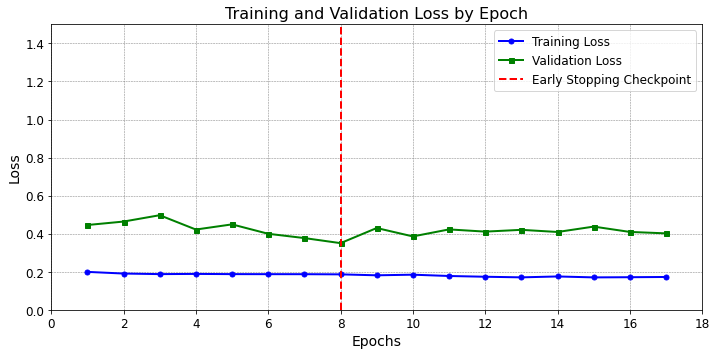

In [60]:
plot_losses(train_losses, valid_losses)

## Testing

### Load Best Model

In [61]:
model.load_state_dict(torch.load(best_model + file_name))

<All keys matched successfully>

### Test Loop

In [62]:
def test_model(model, dataloader):
    
    model.eval()

    with torch.no_grad():

        total = 0
        labels = []
        predictions = []
        all_embeddings = []

        for x, y, l in dataloader:

            x = x.to(device)
            y = y.to(device)
            l = l.cpu()
            y = y.long()

            embeddings, outputs = model(x, l)
            
            embeddings = embeddings.detach().cpu().numpy()
            all_embeddings.extend(embeddings)
            
            prediction = nn.Softmax(dim=1)(outputs)
            prediction = prediction.detach().cpu().numpy()
            prediction = prediction[:,1]
            
            label = y.detach().cpu().numpy()

            labels.extend(label)
            predictions.extend(prediction)

        labels = np.array(labels)
        predictions = np.array(predictions)
    
    return labels, predictions, all_embeddings

In [63]:
train_dataset = Data(X_data_train, y_train, X_len_train)
train_loader_no_sampler = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, **kwargs)

In [64]:
test_true_labels , test_prediction_probs , test_embeddings  = test_model(model, test_loader)
train_true_labels, train_prediction_probs, train_embeddings = test_model(model, train_loader_no_sampler)
valid_true_labels, valid_prediction_probs, valid_embeddings = test_model(model, valid_loader)

### Calibration

In [65]:
def calibrate_probabilities(predicted_probabilities, true_labels):

    predicted_probabilities = np.asarray(predicted_probabilities)
    true_labels = np.asarray(true_labels)

    isotonic_regressor = IsotonicRegression(out_of_bounds='clip')
    isotonic_regressor.fit(predicted_probabilities, true_labels)

    calibrated_probabilities = isotonic_regressor.transform(predicted_probabilities)

    return isotonic_regressor

In [66]:
true_labels_tv = np.concatenate([train_true_labels, valid_true_labels], axis=0)
pred_probs_tv  = np.concatenate([train_prediction_probs,  valid_prediction_probs],  axis=0)

isotonic_regressor = calibrate_probabilities(pred_probs_tv, true_labels_tv)
# test_prediction_probs = isotonic_regressor.transform(test_prediction_probs)

### LSTM Result

In [68]:
train_result['LSTM_PREDICT_PROB'] = train_prediction_probs 
train_result['LSTM_LABEL'] = train_true_labels 

valid_result['LSTM_PREDICT_PROB'] = valid_prediction_probs 
valid_result['LSTM_LABEL'] = valid_true_labels 

test_result['LSTM_PREDICT_PROB'] = test_prediction_probs 
test_result['LSTM_LABEL'] = test_true_labels 

print(train_result[train_result.ICU_EXPIRE_FLAG != train_result.LSTM_LABEL].shape)
print(valid_result[valid_result.ICU_EXPIRE_FLAG != valid_result.LSTM_LABEL].shape)
print(test_result[test_result.ICU_EXPIRE_FLAG   != test_result.LSTM_LABEL].shape)

(0, 8)
(0, 8)
(0, 8)


### Embeddings

In [69]:
encoding_dim = 2 * lstm_hidden_size

In [70]:
train_encoded_df = pd.DataFrame(np.array(train_embeddings), columns=[f'embeded_dim{i+1}' for i in range(encoding_dim)])
train_encoded_df['prediction'] = train_prediction_probs 
train_encoded_df['label'] = train_true_labels 

valid_encoded_df = pd.DataFrame(np.array(valid_embeddings), columns=[f'embeded_dim{i+1}' for i in range(encoding_dim)])
valid_encoded_df['prediction'] = valid_prediction_probs 
valid_encoded_df['label'] = valid_true_labels 

test_encoded_df = pd.DataFrame(np.array(test_embeddings), columns=[f'embeded_dim{i+1}' for i in range(encoding_dim)])
test_encoded_df['prediction'] = test_prediction_probs 
test_encoded_df['label'] = test_true_labels 

In [71]:
train_result = pd.concat([train_result, train_encoded_df], axis=1)
valid_result = pd.concat([valid_result, valid_encoded_df], axis=1)
test_result  = pd.concat([test_result,  test_encoded_df],  axis=1)

In [72]:
train_result['all_matching'] = train_result.apply(lambda x: x.ICU_EXPIRE_FLAG == x.LSTM_LABEL == x.label, axis = 1)
valid_result['all_matching'] = valid_result.apply(lambda x: x.ICU_EXPIRE_FLAG == x.LSTM_LABEL == x.label, axis = 1)
test_result['all_matching']  = test_result.apply(lambda  x: x.ICU_EXPIRE_FLAG == x.LSTM_LABEL == x.label, axis = 1)

print(train_result[train_result.all_matching == False].shape)
print(valid_result[valid_result.all_matching == False].shape)
print(test_result[test_result.all_matching   == False].shape)

(0, 267)
(0, 267)
(0, 267)


### ROC

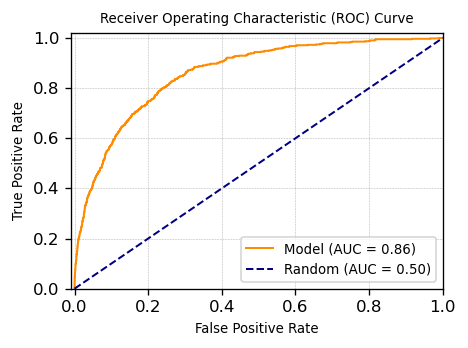

In [73]:
ROC_curve(test_result.ICU_EXPIRE_FLAG, test_result.LSTM_PREDICT_PROB)

### Precision - Recall

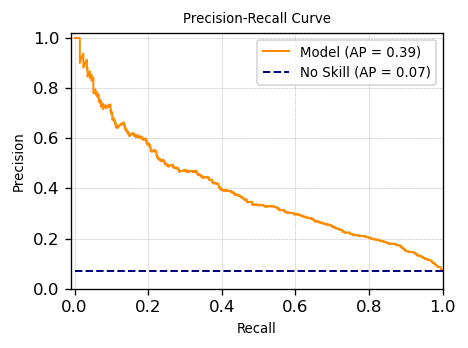

In [74]:
PRC_REC_curve(test_result.ICU_EXPIRE_FLAG, test_result.LSTM_PREDICT_PROB)

### Set Decision Threshold

In [76]:
decision_recall = 0.8

In [77]:
predicted_label_lstm, decision_threshold_lstm = Prediction_Labels_Thresholding(test_result.ICU_EXPIRE_FLAG, 
                                                                               test_result.LSTM_PREDICT_PROB, 
                                                                               decision_recall)

test_result['LSTM_PREDICT_LABEL'] = predicted_label_lstm

Decision Threshold is:  0.36


In [78]:
predicted_label_lstm, decision_threshold_lstm = Prediction_Labels_Thresholding(train_result.ICU_EXPIRE_FLAG, 
                                                                               train_result.LSTM_PREDICT_PROB, 
                                                                               decision_recall)

train_result['LSTM_PREDICT_LABEL'] = predicted_label_lstm

Decision Threshold is:  0.92


In [79]:
predicted_label_lstm, decision_threshold_lstm = Prediction_Labels_Thresholding(valid_result.ICU_EXPIRE_FLAG, 
                                                                               valid_result.LSTM_PREDICT_PROB, 
                                                                               decision_recall)

valid_result['LSTM_PREDICT_LABEL'] = predicted_label_lstm

Decision Threshold is:  0.25


### Confusion Matrix

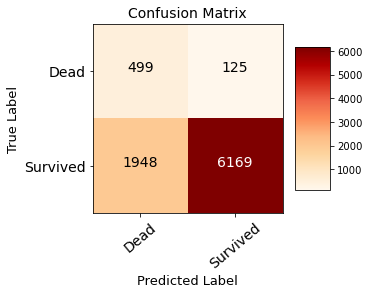

In [80]:
Confusion_Matrix(test_result.ICU_EXPIRE_FLAG, test_result.LSTM_PREDICT_LABEL, classes = ['Dead', 'Survived'])

### Performance Metrics

In [81]:
Performance_Metrics(test_result.ICU_EXPIRE_FLAG, test_result.LSTM_PREDICT_LABEL, test_result.LSTM_PREDICT_PROB)

ACC =  0.76
PRC =  0.2
REC =  0.8
F1M =  0.32
PPV =  0.2
NPV =  0.98
SEN =  0.8
SPE =  0.76
FPR =  0.24
FNR =  0.2
FDR =  0.8
AUC =  0.86
AP  =  0.39
MCC =  0.32


### Distribution of Prediction Probabilities

In [82]:
df_prediction_lstm_alive = test_result[test_result['ICU_FLAG'] == 'Survived']
df_prediction_lstm_dead  = test_result[test_result['ICU_FLAG'] == 'Dead']

### Alive Patients

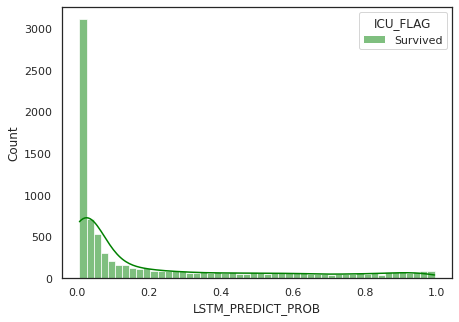

In [83]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_lstm_alive, x='LSTM_PREDICT_PROB', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['green'])
plt.show()

### Dead Patients

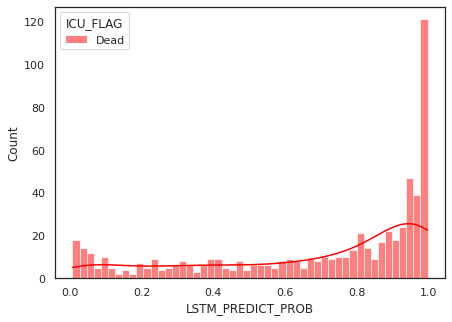

In [84]:
plt.figure(figsize=(7, 5))
sns.set(font_scale= 1)
sns.set_style(style='white')
sns.histplot(data=df_prediction_lstm_dead, x='LSTM_PREDICT_PROB', kde=True, stat='count', bins=50, fill=True,
             legend=True, hue='ICU_FLAG', palette=['red'])
plt.show()

### LSTM 

ROC AUC:  0.86
PR  AUC:  0.39
                   ________________________
                  |  Classification Report |
                   ‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾‾
              precision    recall  f1-score   support

    Negative       0.98      0.71      0.82      8117
    Positive       0.18      0.85      0.30       624

    accuracy                           0.72      8741
   macro avg       0.58      0.78      0.56      8741
weighted avg       0.93      0.72      0.79      8741

None


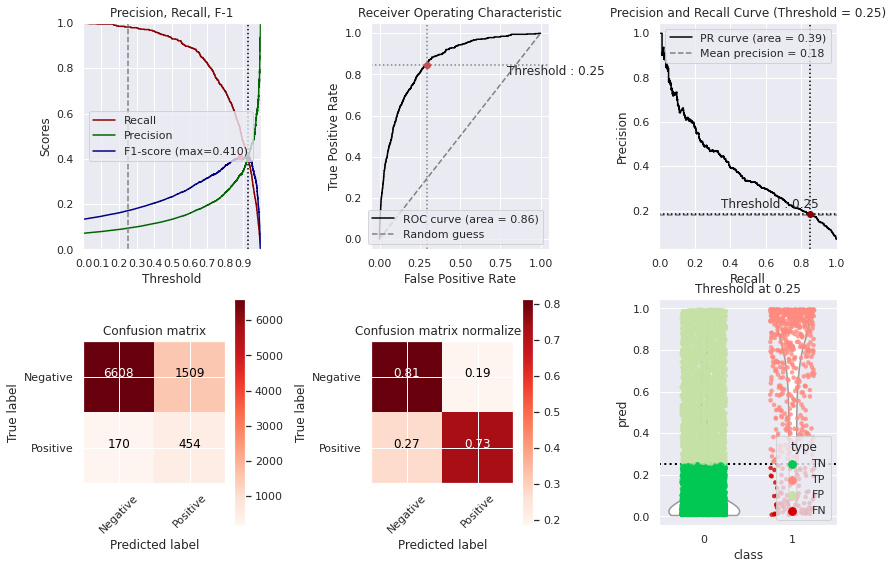

In [85]:
Binary_Classification_Performance(test_result.ICU_EXPIRE_FLAG, test_result.LSTM_PREDICT_PROB, decision_threshold_lstm)

### Save Results

In [86]:
concat_ehr = [train_result, valid_result, test_result]
ehr_lstm_representation = pd.concat(concat_ehr)

ehr_lstm_representation.head(3)

In [87]:
# ehr_lstm_representation.to_csv(path_data + "text_lstm_representation.csv", index=False)
# test_result.to_csv("./Results/LLM_LSTM_24H_Result.csv", index=False)
# test_result.to_csv("./Results/LSTM_Result_Cal.csv", index=False)